In [2]:
import numpy as np
import disc2radmc 
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits
from matplotlib.patches import Ellipse
from os.path import expanduser
import functions_image as fim
home = expanduser("~")

In [61]:
def Sigma_dust(r, phi, a, rc1, rc2, sigr, C, ac):
    # r: radial distance [au]
    # phi: azimuthal angle [rad]
    # a: grain size [um]
    # parameters defined by the user, e.g. gaussian radius, width, critical grain size, etc.


    if a<=ac:
        rc_a= rc1 # * np.exp( np.log(a/amin) * np.log(rmax/rmin)/np.log(ac/amin))
        A=C
    else:
        rc_a=rc2
        A=0.0
    return np.exp( -0.5 * ((r-rc_a)/sigr)**2.)*(1.+A*np.cos(phi))



In [97]:
########################
###### PARAMETERS ######
########################

## STAR
dpc=50.0  # [pc] distance to source 
target='HDsegregated'# name
Rstar=1.0 # [Solar radii]
Tstar= 6000 # [K] If this is negative, the code will consider the star as a blackbody. 
g=4.0
# For a realistic stellar model, you can download bt-settl models 
# from http://svo2.cab.inta-csic.es/theory/newov2/index.php and indicate their directory below
dir_stellar_templates=home+'/Astronomy/Stellar_templates/BT-Settl/bt-settl/'
# The code will then search for files named as 
# dir_stellar_templates+'lte%03i-%1.1f-0.0a+0.0.BT-NextGen.7.dat.txt'%(Tstar//100,g) if Tstar>=2600
# dir_stellar_templates+'lte%03i-%1.1f-0.0.BT-Settl.7.dat.txt'%(T//100,g)            else
# and interpolate models with neighbouring temperatures if necessary

## DUST

# size dist
amin=1.0       # [mu]  minimum grain size (1 by default)
amax=1.0e4     # [mu]  maximum grain size (1e4 by default)
N_species=30    #  (1 by default) Number of dust size bins to use for the radiative transfer calculations. 
slope = -3.5   #  (-3.5 by default) Slope of the size distribution. This is used for computing opacities and for the mass distribution of each size bin

# density distribution
tag='default'
Mdust=0.1      # [Mearth] Total dust mass
rc1=120.    # [au] critical radius for smaller grains
rc2=90.     # [au] critical radius for larger grains
sigr=15.       # [au] width of the Gaussian distribution (standard deviation)
ac=100.0 # [um] critical grain size for size segregation. Grains smaller than this will be distributed with rc1, while larger grains will be distributed with rc2.
C=1.0 # amplitude of the azimuthal asymmetry. This is a constant, but other parametrizations are possible.

h=0.05         # vertical aspect ratio =H/r, where H is the vertical standard deviation. This is a constant, but other parametrizations are possible and will be shown below. 

par_sigma=(rc1, rc2, sigr, C, ac) # list containing the parameters that define the dust surface density. They must be in the same order as in the definition of Sigma_dust
size_segregation=True


## MODEL SPATIAL GRID
rmin=30. # [au] make sure it is small enough to sample the surface density
rmax=200.# [au] 
Nr=200    # radial cells (linearly or logspaced)
Nphi=300 # azimuthal cells
Nth=15   # polar angle cells
thmax=np.arctan(h)*3 # maximum polar angle to sample as measured from the midplane.
axisym=False # Consider the disc to be axisymmetric to speed up calculations? it can overwrite Nphi if True and set it to 1
mirror=True  # Mirror the upper half to speed up calculations. This is incompatible with anisotropic scattering.
logr=True # Sample r logarithmically or linearly

# WAVELENGTH GRID (grid to sample the stellar flux in temperature calculations, see radmc3d manual)
lammin=0.1  # [mu]  minimum wavelength to consider in our model (important for temperature calculation)
lammax=1.0e5 # [mu] minimum wavelength to consider in our model (important for temperature calculation)
Nlam=150     # number of cells logarithmically spaced to sample the wavelength range.

# IMAGE PARAMETERS
Npix=512  # number of pixels
dpix=0.01 # pixel size in arcsec
inc=45.    # [deg] inclination
PA=28.    # [deg] position angle

scattering_mode=0 # scattering mode (0=no scattering, 1=isotropic, 2=anisotropic using H&G function)

In [98]:
### PHYSICAL GRID
gridmodel=disc2radmc.physical_grid(rmin=rmin, rmax=rmax, Nr=Nr, Nphi=Nphi, Nth=Nth, thmax=thmax, mirror=mirror, logr=logr, axisym=axisym)
gridmodel.save()

### WAVELENGTH GRID
lammodel=disc2radmc.wavelength_grid(lammin=lammin, lammax=lammax, Nlam=Nlam)
lammodel.save()

### STAR
starmodel=disc2radmc.star(lammodel,
                          Tstar=Tstar,
                          Rstar=Rstar,
                          g=g,
                          dir_stellar_templates=dir_stellar_templates # necessary line if Tstar>0
                        )
starmodel.save()

In [99]:
### DUST SIZE DISTRIBUTION AND OPACITY
# path to optical constants that can be found at
# https://github.com/SebaMarino/disc2radmc/tree/main/opacities/dust_optical_constants
path_opct=home+'/Astronomy/Codes/packages/disc2radmc/opacities/dust_optical_constants/' 
lnk_files=[path_opct+'Sil_0.1_10000.lnk',
           path_opct+'ac_opct.lnk',
           path_opct+'ci_60K_0.1_10000.lnk']
densities=[4., 3., 1.] # densities in g/cm3
mass_weights=[40., 30., 30.] # mixing ratios by mass
dust=disc2radmc.dust(lammodel,
                           Mdust=Mdust,
                           lnk_file=lnk_files,
                           densities=densities,
                           N_species=N_species,
                           slope=slope,
                           N_per_bin=30, # number of species per size bin to have a good representation 
                           amin=amin,
                           amax=amax,
                           mass_weights=mass_weights,
                           tag='mix', # name to give to this new mixed species
                           compute_opct=True) 

Compute average optical constants
final density = 2.0 g/cm3


In [ ]:
# this only needs to be run once, unless you change the dust properties (e.g. size distribution, composition, etc.)
dust.compute_opacities()
# this might produce two messages about some files not existing when trying to remove them with rm

rm: ./Tempkappa/*: No such file or directory
rm: ./param.inp: No such file or directory


In [101]:
### DUST DENSITY DISTRIBUTION
dust.dust_densities(grid=gridmodel,
                    function_sigma=Sigma_dust,
                    par_sigma=par_sigma, 
                    h=h, 
                    size_segregation=size_segregation)
dust.write_density()

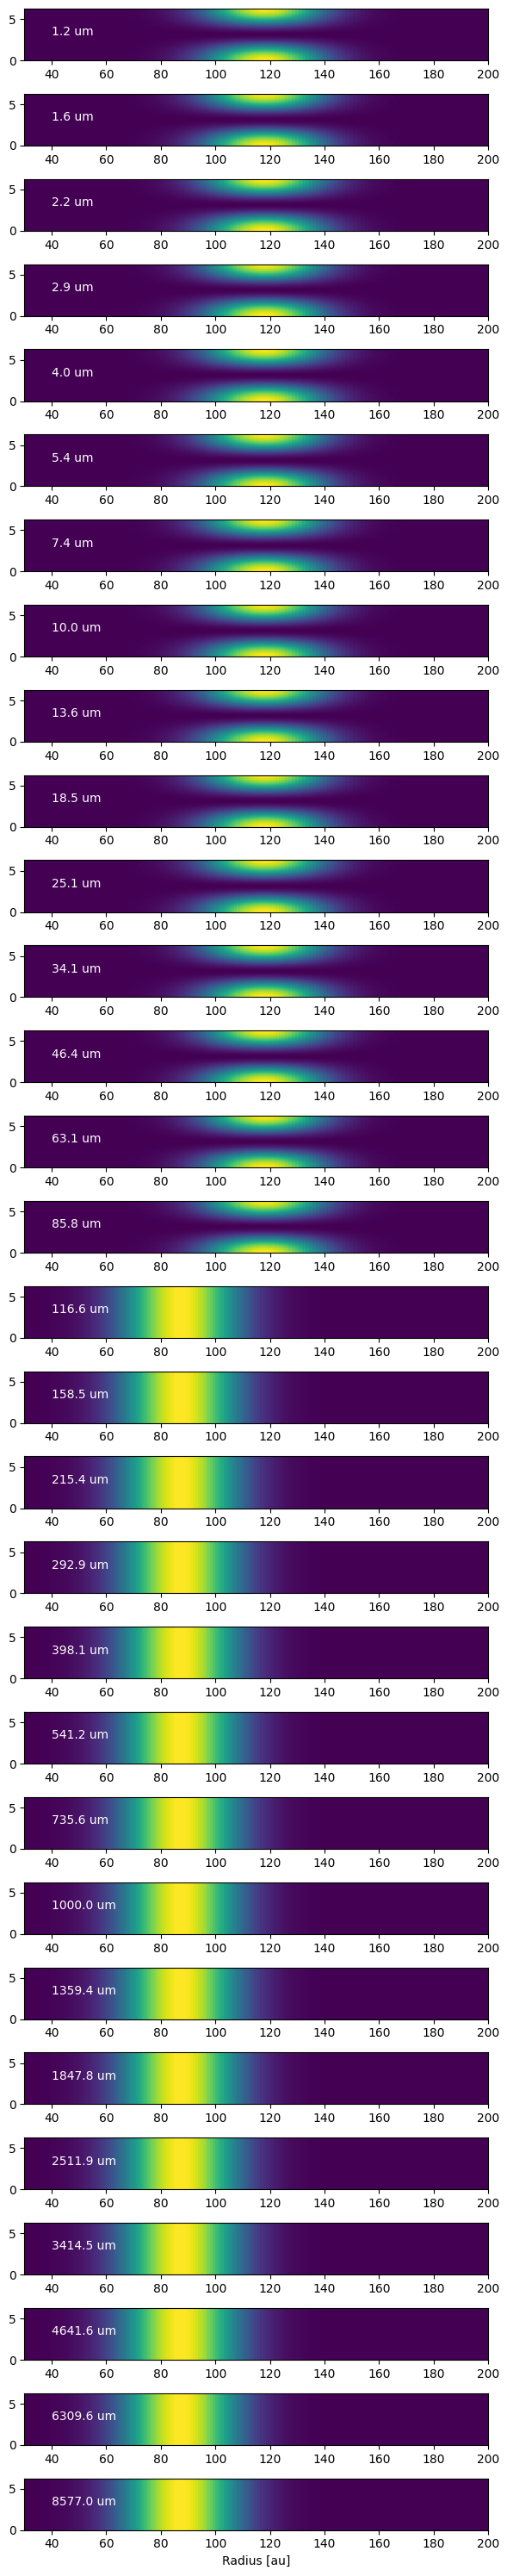

In [103]:
# plot dust densities for different dust species

# check density (northern emisphere)
if mirror:
    Density=np.loadtxt('./dust_density.inp', max_rows=dust.N_species*gridmodel.Nr*gridmodel.Nphi*gridmodel.Nth, dtype=float, skiprows=3).reshape( (dust.N_species, gridmodel.Nphi, gridmodel.Nth, gridmodel.Nr))
else:
    Density=np.loadtxt('./dust_density.inp', max_rows=dust.N_species*gridmodel.Nr*gridmodel.Nphi*gridmodel.Nth*2, dtype=float, skiprows=3).reshape( (dust.N_species, gridmodel.Nphi, gridmodel.Nth*2, gridmodel.Nr))

# Density vertical dimension is flipped, starting from Northern emisphere (maxtheta) to Southern hemisphere 

fig, axs=plt.subplots(nrows=dust.N_species, ncols=1, figsize=(6,1*dust.N_species))

plot = 'azimuthal' # 'polar' or 'azimuthal'
for i, axi in enumerate(axs):
    
    if plot == 'azimuthal':
        pc1=axi.pcolormesh(gridmodel.redge, gridmodel.phiedge, Density[i, :,gridmodel.Nth-1,:])
        axi.text(40., 3., '{:.1f} um'.format(dust.Agrid[i]), color='white')

    elif plot == 'polar':
        axi.text(40., 0.1, '{:.1f} um'.format(dust.Agrid[i]), color='white')
        pc2=axi.pcolormesh(gridmodel.redge, gridmodel.thedge[::-1], Density[i,0,:gridmodel.Nth,:])

axi.set_xlabel('Radius [au]')

plt.tight_layout()

#axi.set_xscale('log')
#axi.set_ylabel(r'Azimuthal angle [rad]')
# ax2.set_ylabel(r'Polar angle [rad]')

#fig.colorbar(pc1, ax=axi,label='Density [g/cm3]')


In [104]:
sim=disc2radmc.simulation(nphot=10000000, # number of photon packages for thermal monte carlo
                            nphot_scat=1000000, # number of photon packages for image
                            nphot_spec=10000,   # number of photon packages for spectrum
                            nphot_mono=10000,   # number of photon packages for the monochromatic monte carlo
                            scattering_mode=scattering_mode, 
                            incl_lines=0, # whether to include gas lines (1) or not (0)
                            modified_random_walk=0, # for very optically thick medium, this is a useful approximation
                            istar_sphere=0, # consider the star a sphere or a point.
                            tgas_eq_tdust=1, # gas temperature equal to the temperature of the first dust species
                            setthreads=4,
                            verbose=True, 
                            )

### RUN MCTHERM to compute temperature
sim.mctherm()

  
      WELCOME TO RADMC-3D: A 3-D CONTINUUM AND LINE RT SOLVER    
                                                                 
                          VERSION 2.0                            
                                                                 
                (c) 2008-2023 Cornelis Dullemond                 
                                                                 
       Please feel free to ask questions. Also please report     
        bugs and/or suspicious behavior without hestitation.     
      The reliability of this code depends on your vigilance!    
                    dullemond@uni-heidelberg.de                  
                                                                 
   To keep up-to-date with bug-alarms and bugfixes, follow the   
                     RADMC-3D code on github                     
             https://github.com/dullemond/radmc3d-2.0            
                                                                 
       

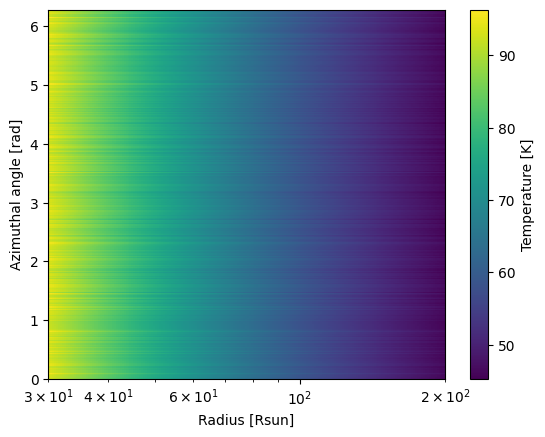

In [105]:
# check temperature (northern emisphere)
Ts=np.fromfile('./dust_temperature.bdat', count=gridmodel.Nr*gridmodel.Nphi*gridmodel.Nth+4, dtype=float)[4:].reshape( (gridmodel.Nphi, gridmodel.Nth, gridmodel.Nr))
plt.pcolormesh(gridmodel.redge, gridmodel.phiedge[::-1], Ts[:,0,:])
#plt.pcolormesh(gridmodel.redge, gridmodel.thedge[::-1], Ts[0,:gridmodel.Nth,:])

plt.xlabel('Radius [Rsun]')
plt.xscale('log')
plt.ylabel(r'Azimuthal angle [rad]')
#plt.ylabel(r'Polar angle [rad]')
plt.colorbar(label='Temperature [K]')
plt.show()

In [106]:
### MAKE IMAGE

wavelengths=np.array([ 400, 880., 1300.]) #20.0

sim.simimage(dpc=dpc, 
             # imagename='{:.1f}'.format(wavelength), 
             # wavelength=wavelength,
             imagename=tag, 
             wavelength=wavelengths,
             Npix=Npix,
             dpix=dpix,
             inc=inc,
             PA=PA,
             tag=target,
             fstar=0.)

image size = 2.6e+02 au
radmc3d image incl 45.00000  phi  0.00000 posang -62.00000  npix 512  loadlambda sizeau 256.00000  secondorder
  
      WELCOME TO RADMC-3D: A 3-D CONTINUUM AND LINE RT SOLVER    
                                                                 
                          VERSION 2.0                            
                                                                 
                (c) 2008-2023 Cornelis Dullemond                 
                                                                 
       Please feel free to ask questions. Also please report     
        bugs and/or suspicious behavior without hestitation.     
      The reliability of this code depends on your vigilance!    
                    dullemond@uni-heidelberg.de                  
                                                                 
   To keep up-to-date with bug-alarms and bugfixes, follow the   
                     RADMC-3D code on github                     
    

(3, 512, 512)
512 512
wavelength = 880.000 um
2.5600364377378746 2.5600364377378746
Nfx, Nfy =  512 512
(3, 512, 512)


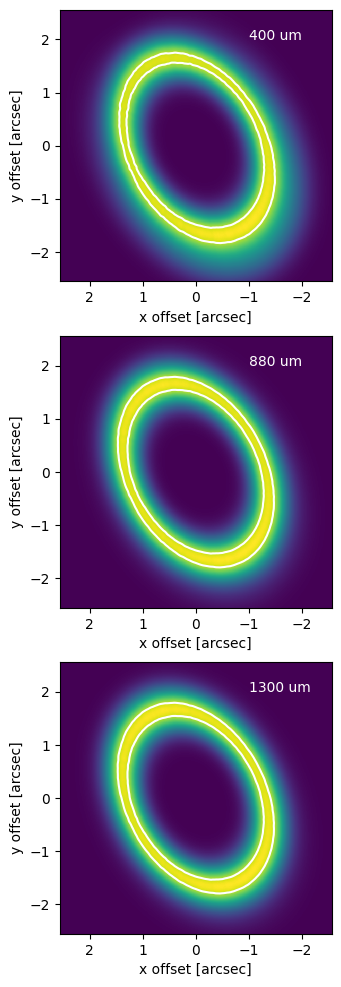

In [108]:
cube, xf, yf =fim.fload_fits_image('./images/image_{}_{}.fits'.format(tag, target))
xc=(xf[1:]+xf[:-1])/2.
yc=(yf[1:]+yf[:-1])/2.
xm, ym =np.meshgrid(xc, yc)
r=np.sqrt(xm**2+ym**2)

print(cube.shape)
Nw=cube.shape[0]

# print(cube.shape)

fig=plt.figure(figsize=(4,4*Nw))

for i in range(Nw):

    image=cube[i]
    axi=fig.add_subplot(Nw, 1,i+1)
    

    axi.pcolormesh(xf, yf, image)
    axi.contour(xc, yc, image, colors='white', levels=[0.9*np.max(image)])
    axi.set_aspect('equal')

    axi.set_xlim(xf[0], xf[-1])
    axi.set_ylim(yf[0], yf[-1])
    axi.set_xlabel('x offset [arcsec]')
    axi.set_ylabel('y offset [arcsec]')
    axi.text(-1., 2., '{:.0f} um'.format(wavelengths[i]), color='white')

